In [15]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import re
from scipy import signal

import tensorflow as tf
import itertools

In [4]:
path = Path("motion_sense_accelerometer")

classes = {'dws': 0, 'ups': 1, 'sit': 2, 'std': 3, 'wlk': 4, 'jog': 5}

train_idxs, val_idxs, test_idxs = np.arange(0, 19), np.arange(19, 22), np.arange(22, 25)

lens = []

In [24]:
def _get_ds(data, labels, samples):
    ds = tf.data.Dataset.from_generator(lambda: itertools.zip_longest(data, labels), 
                                              output_types=(tf.float64, tf.int32), output_shapes=((4000, 1), ()))
    ds = ds.map(lambda x, y: (tf.py_function(_resample_func, [x, 4000], Tout=tf.float32), y))
    return ds

In [25]:
ds = _get_ds(train_data, train_labels, 4000)
ds

<MapDataset element_spec=(TensorSpec(shape=<unknown>, dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>

In [26]:
for d in ds:
    print(d)
    break

2023-01-25 13:26:40.295341: W tensorflow/core/framework/op_kernel.cc:1818] INVALID_ARGUMENT: TypeError: `generator` yielded an element of shape (4000, 1) where an element of shape (4000,) was expected.
Traceback (most recent call last):

  File "/home/rgroh/anaconda3/envs/evo_nas/lib/python3.9/site-packages/tensorflow/python/ops/script_ops.py", line 271, in __call__
    ret = func(*args)

  File "/home/rgroh/anaconda3/envs/evo_nas/lib/python3.9/site-packages/tensorflow/python/autograph/impl/api.py", line 642, in wrapper
    return func(*args, **kwargs)

  File "/home/rgroh/anaconda3/envs/evo_nas/lib/python3.9/site-packages/tensorflow/python/data/ops/dataset_ops.py", line 1076, in generator_py_func
    raise TypeError(

TypeError: `generator` yielded an element of shape (4000, 1) where an element of shape (4000,) was expected.


2023-01-25 13:26:40.301076: W tensorflow/core/framework/op_kernel.cc:1818] INVALID_ARGUMENT: TypeError: `generator` yielded an element of shape (4000, 1) where 

InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} TypeError: `generator` yielded an element of shape (4000, 1) where an element of shape (4000,) was expected.
Traceback (most recent call last):

  File "/home/rgroh/anaconda3/envs/evo_nas/lib/python3.9/site-packages/tensorflow/python/ops/script_ops.py", line 271, in __call__
    ret = func(*args)

  File "/home/rgroh/anaconda3/envs/evo_nas/lib/python3.9/site-packages/tensorflow/python/autograph/impl/api.py", line 642, in wrapper
    return func(*args, **kwargs)

  File "/home/rgroh/anaconda3/envs/evo_nas/lib/python3.9/site-packages/tensorflow/python/data/ops/dataset_ops.py", line 1076, in generator_py_func
    raise TypeError(

TypeError: `generator` yielded an element of shape (4000, 1) where an element of shape (4000,) was expected.


	 [[{{node PyFunc}}]] [Op:IteratorGetNext]

In [6]:
def _resample_func(x, samples):
    x = signal.resample(x, samples, axis=0)
    return x[..., np.newaxis]

In [7]:
train_data, val_data, test_data = [], [], []
train_labels, val_labels, test_labels = [], [], []

for folder in os.listdir(path):
    class_path = path / folder
    for f in os.listdir(class_path):
        df = pd.read_csv(class_path / f)
        
        x, y, z = np.asarray(df['x']), np.asarray(df['y']), np.asarray(df['z'])
        magnitude = list(np.sqrt(np.square(x) + np.square(y) + np.square(z)))
        magnitude = _resample_func(magnitude, 4_000)
        label = classes[folder[0:3]]
    
        idx = int(re.findall(r'\d+', f)[0])
        if idx in train_idxs:
            train_data.append(magnitude)
            train_labels.append(label)
        elif idx in val_idxs:
            val_data.append(magnitude)
            val_labels.append(label)
        else:
            test_data.append(magnitude)
            test_labels.append(label)


(array([ 98., 117.,  56.,  30.,  23.,  17.,  14.,   4.,   0.,   1.]),
 array([  396. ,  2018.6,  3641.2,  5263.8,  6886.4,  8509. , 10131.6,
        11754.2, 13376.8, 14999.4, 16622. ]),
 <BarContainer object of 10 artists>)

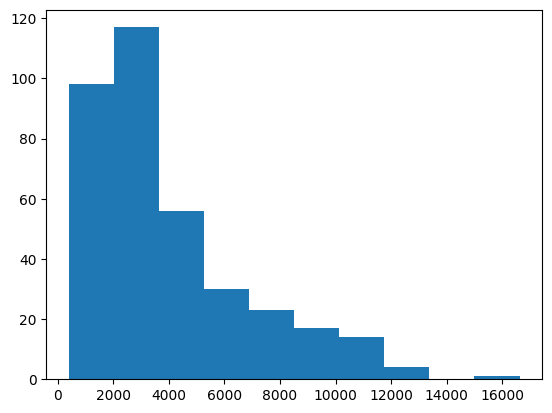

In [78]:
plt.hist(lens)

In [26]:
import matplotlib.pyplot as plt

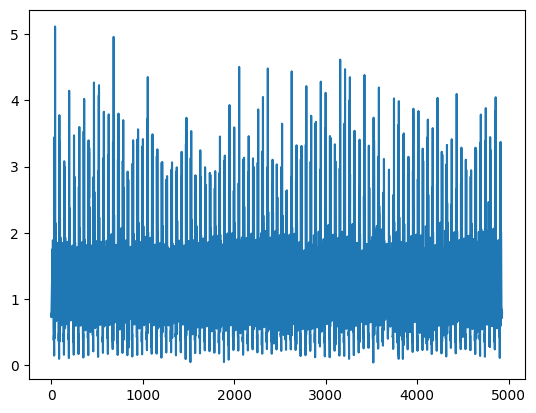

In [29]:
plt.plot(train_data[5])

In [85]:
import tensorflow as tf
import itertools
from scipy import signal

In [89]:
ds_train = tf.data.Dataset.from_generator(lambda: itertools.zip_longest(train_data, train_labels), 
                                          output_types=(tf.float64, tf.int32))

In [86]:
def _resample_func(x, samples):
    x = signal.resample(x, samples, axis=0)
    return x[..., np.newaxis]

In [90]:
ds_train = ds_train.map(lambda x, y: (tf.py_function(_resample_func, [x, 4000], Tout=tf.float32), y))

In [91]:
for d in ds_train:
    print(d)
    break

(<tf.Tensor: shape=(4000, 1), dtype=float32, numpy=
array([[0.9203167 ],
       [1.1350547 ],
       [1.1421471 ],
       ...,
       [0.35611516],
       [0.3889173 ],
       [0.39966896]], dtype=float32)>, <tf.Tensor: shape=(), dtype=int32, numpy=4>)
